# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [24]:
df_raw = pd.read_csv('data/checker_submits.csv')

print(df_raw.shape)
print(df_raw.head())

(1686, 4)
      uid   labname  numTrials                   timestamp
0  user_4  project1          1  2020-04-17 05:19:02.744528
1  user_4  project1          2  2020-04-17 05:22:45.549397
2  user_4  project1          3  2020-04-17 05:34:24.422370
3  user_4  project1          4  2020-04-17 05:43:27.773992
4  user_4  project1          5  2020-04-17 05:46:32.275104


In [25]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['dayofweek'] = df_raw['timestamp'].dt.dayofweek

df_raw.head()

,uid,labname,numTrials,timestamp,hour,dayofweek
0,user_4,project1,1,2020-04-17 05:19:02.744528,5,4
1,user_4,project1,2,2020-04-17 05:22:45.549397,5,4
2,user_4,project1,3,2020-04-17 05:34:24.422370,5,4
3,user_4,project1,4,2020-04-17 05:43:27.773992,5,4
4,user_4,project1,5,2020-04-17 05:46:32.275104,5,4


In [26]:
df = df_raw[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']].copy()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   uid        1686 non-null   str  
 1   labname    1686 non-null   str  
 2   numTrials  1686 non-null   int64
 3   hour       1686 non-null   int32
 4   dayofweek  1686 non-null   int32
dtypes: int32(2), int64(1), str(2)
memory usage: 52.8 KB


In [27]:
categorical_features = ['uid', 'labname']

encoder = OneHotEncoder()
cat_encoded = encoder.fit_transform(df[categorical_features])
cat_feature_names = encoder.get_feature_names_out(categorical_features)

df[cat_feature_names] = cat_encoded.toarray()
df.drop(columns=categorical_features, inplace=True)

print(f'Добавлено признаков в результате кодирования: {len(cat_feature_names)}')

Добавлено признаков в результате кодирования: 41


In [28]:
continuous_features = ['numTrials', 'hour']

df[continuous_features] = StandardScaler().fit_transform(df[continuous_features])

df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   numTrials         1686 non-null   float64
 1   hour              1686 non-null   float64
 2   dayofweek         1686 non-null   int32  
 3   uid_user_0        1686 non-null   float64
 4   uid_user_1        1686 non-null   float64
 5   uid_user_10       1686 non-null   float64
 6   uid_user_11       1686 non-null   float64
 7   uid_user_12       1686 non-null   float64
 8   uid_user_13       1686 non-null   float64
 9   uid_user_14       1686 non-null   float64
 10  uid_user_15       1686 non-null   float64
 11  uid_user_16       1686 non-null   float64
 12  uid_user_17       1686 non-null   float64
 13  uid_user_18       1686 non-null   float64
 14  uid_user_19       1686 non-null   float64
 15  uid_user_2        1686 non-null   float64
 16  uid_user_20       1686 non-null   float64
 17  uid_us

In [30]:
df.to_csv('data/dayofweek.csv', index=False)

In [31]:
feature_names = [c for c in df.columns if c != 'dayofweek']

X = df[feature_names]
y = df['dayofweek']

most_common_class = y.mode()[0]
y_naive = np.full_like(y, most_common_class)
accuracy_naive = accuracy_score(y, y_naive)

print(f'Accuracy наивного "классификатора": {accuracy_naive}')

Accuracy наивного "классификатора": 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [32]:
logreg = LogisticRegression(random_state=21, fit_intercept=False).fit(X, y)

y_pred_logreg = logreg.predict(X)

accuracy_logreg = accuracy_score(y, y_pred_logreg)

print(f"Accuracy логистической регрессии: {accuracy_logreg}")
print(f'Улучшение по сравнению с наивным "классификатором": {(accuracy_logreg - accuracy_naive)}')

Accuracy логистической регрессии: 0.6405693950177936
Улучшение по сравнению с наивным "классификатором": 0.40569395017793597


In [33]:
def plot_feature_importance(importances, feature_names, top_n, title):
    top_idx = np.argsort(importances)[-top_n:][::-1]
    values = importances[top_idx]
    names = [feature_names[i] for i in top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), values, alpha=0.7)
    plt.yticks(range(top_n), names)
    plt.gca().invert_yaxis()
    plt.xlabel('Значимость')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

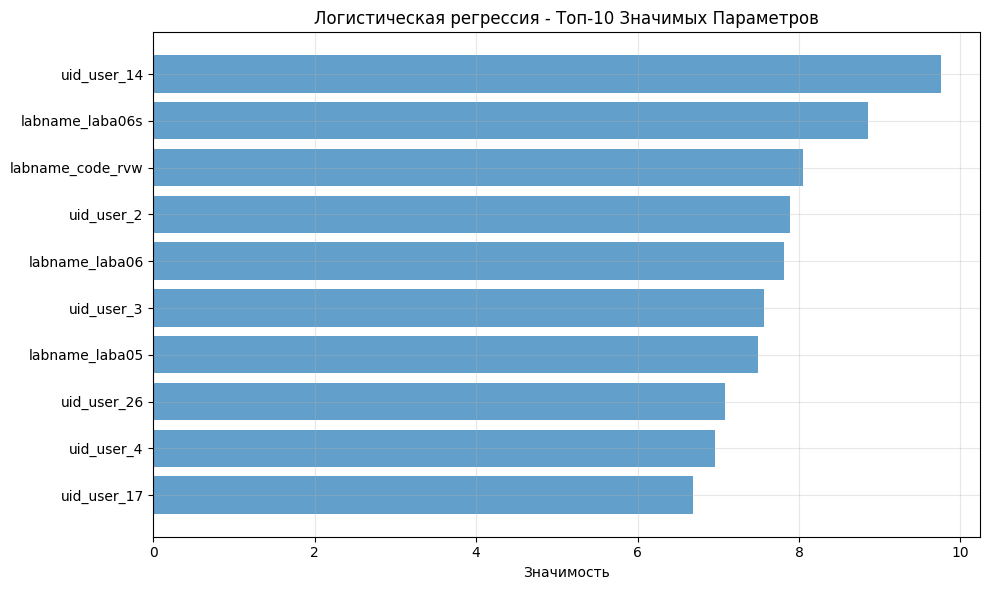

In [34]:
logreg_importances = np.abs(logreg.coef_).sum(axis=0)

plot_feature_importance(logreg_importances, feature_names, 10,
                        title="Логистическая регрессия - Топ-10 Значимых Параметров")

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [35]:
svc_linear = SVC(kernel='linear', probability=True, random_state=21).fit(X, y)

y_pred_svc_linear = svc_linear.predict(X)
accuracy_svc_linear = accuracy_score(y, y_pred_svc_linear)

print(f"SVC (linear kernel) accuracy: {accuracy_svc_linear}")

SVC (linear kernel) accuracy: 0.702846975088968


In [36]:
kernels = ['linear', 'rbf', 'poly']
svc_models = {}
svc_accuracies = {}

print("\nПоиск лучшего kernel для SVC:")
print("-" * 40)

for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=21).fit(X, y)
    y_pred = svc.predict(X)
    acc = accuracy_score(y, y_pred)
    svc_models[kernel] = svc
    svc_accuracies[kernel] = acc
    print(f"  {kernel:10s}: {acc}")

best_svc_kernel = max(svc_accuracies, key=svc_accuracies.get)
best_svc = svc_models[best_svc_kernel]
best_svc_accuracy = svc_accuracies[best_svc_kernel]

print(f"\nЛучший kernel: {best_svc_kernel} (accuracy = {best_svc_accuracy})")
print("-" * 40)


Поиск лучшего kernel для SVC:
----------------------------------------
  linear    : 0.702846975088968
  rbf       : 0.8558718861209964
  poly      : 0.8594306049822064

Лучший kernel: poly (accuracy = 0.8594306049822064)
----------------------------------------


In [37]:
print(f"\nСравнение SVC с другими моделями:")
print(f"    SVC ({best_svc_kernel} kernel): {best_svc_accuracy}")
print(f"    Логистическая регрессия: {accuracy_logreg}")
print(f"    Наивный классификатор: {accuracy_naive}")


Сравнение SVC с другими моделями:
    SVC (poly kernel): 0.8594306049822064
    Логистическая регрессия: 0.6405693950177936
    Наивный классификатор: 0.23487544483985764


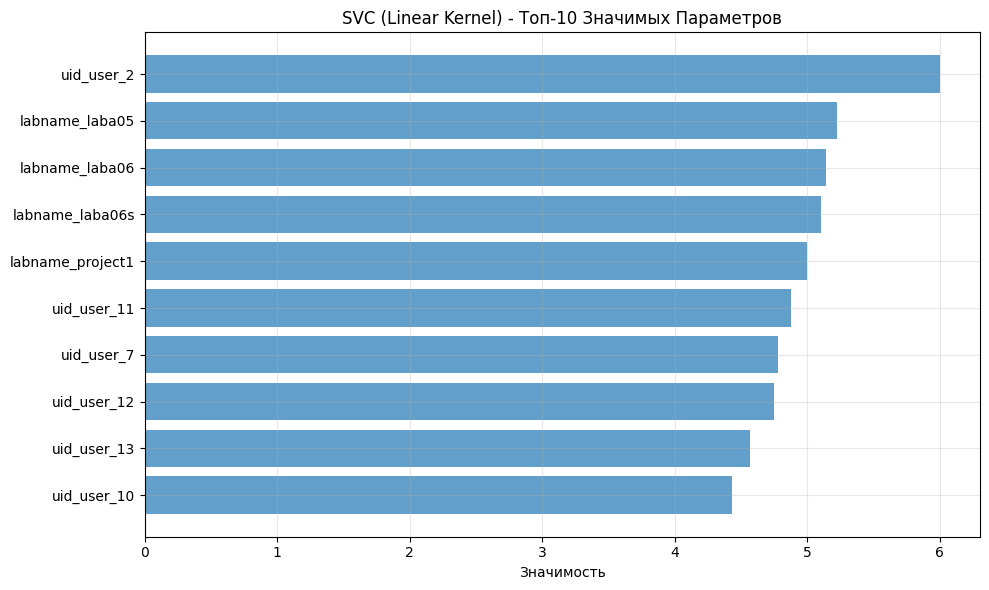

In [38]:
svc_ovr = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21)).fit(X, y)

svc_importances = np.abs(np.vstack([e.coef_ for e in svc_ovr.estimators_])).sum(axis=0)

plot_feature_importance(svc_importances, feature_names, top_n=10,
                        title="SVC (Linear Kernel) - Топ-10 Значимых Параметров")

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [39]:
d_tree = DecisionTreeClassifier(max_depth=4, random_state=21).fit(X, y)

y_pred_dt = d_tree.predict(X)
accuracy_dt = accuracy_score(y, y_pred_dt)

print(f"Accuracy дерева решений (max_depth=4): {accuracy_dt}")

Accuracy дерева решений (max_depth=4): 0.5516014234875445


In [40]:
max_depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]
dt_models = {}
dt_accuracies = {}

print("\nПоиск лучшего max_depth для Decision Tree:")
print("-" * 40)

for md in max_depths:
    dt_test = DecisionTreeClassifier(max_depth=md, random_state=21).fit(X, y)
    y_pred = dt_test.predict(X)
    acc = accuracy_score(y, y_pred)
    dt_models[md] = dt_test
    dt_accuracies[md] = acc
    print(f"  max_depth={md:2d}: {acc}")

best_dt_depth = max(dt_accuracies, key=dt_accuracies.get)
best_dt = dt_models[best_dt_depth]
best_dt_accuracy = dt_accuracies[best_dt_depth]

print(f"\nЛучший max_depth: {best_dt_depth} (accuracy = {best_dt_accuracy})")


Поиск лучшего max_depth для Decision Tree:
----------------------------------------
  max_depth= 1: 0.35765124555160144
  max_depth= 2: 0.4389086595492289
  max_depth= 3: 0.48991696322657174
  max_depth= 4: 0.5516014234875445
  max_depth= 5: 0.6109134045077106
  max_depth= 6: 0.6637010676156584
  max_depth= 7: 0.7064056939501779
  max_depth= 8: 0.7502965599051008
  max_depth=10: 0.8196915776986952
  max_depth=15: 0.9460260972716489

Лучший max_depth: 15 (accuracy = 0.9460260972716489)


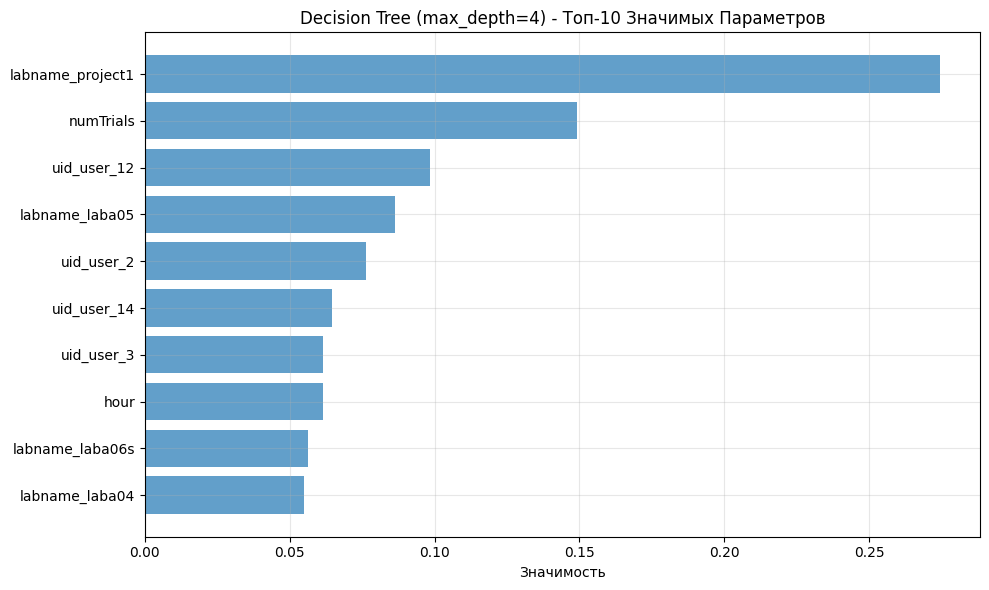

In [41]:
dt_importances = d_tree.feature_importances_

plot_feature_importance(dt_importances, feature_names, top_n=10,
                        title="Decision Tree (max_depth=4) - Топ-10 Значимых Параметров")

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [42]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21).fit(X, y)

y_pred_rf = rf.predict(X)
accuracy_rf = accuracy_score(y, y_pred_rf)

print(f"Accuracy случайного леса (n_estimators = 100, max_depth = 25): {accuracy_rf}")

Accuracy случайного леса (n_estimators = 100, max_depth = 25): 1.0


In [43]:
print("\nПоиск лучших параметров для Random Forest:")
print("-" * 50)
print(f"{'max_depth | n_estimators | Accuracy'}")
print("-" * 50)

rf_models = {}
rf_accuracies = {}

max_depths_rf = [5, 10, 15, 20, 25]
n_estimators_list = [50, 100, 200]

best_rf_accuracy = 0
best_rf_params = {}

for md in max_depths_rf:
    for n_est in n_estimators_list:
        key = (md, n_est)
        rf_test = RandomForestClassifier(n_estimators=n_est, max_depth=md, random_state=21)
        rf_test.fit(X, y)
        y_pred = rf_test.predict(X)
        acc = accuracy_score(y, y_pred)
        rf_models[key] = rf_test
        rf_accuracies[key] = acc
        print(f"{md} | {n_est} | {acc}")
        
        if acc > best_rf_accuracy:
            best_rf_accuracy = acc
            best_rf_params = {'max_depth': md, 'n_estimators': n_est}

print("-" * 50)
print(f"Лучшие параметры: {best_rf_params}")
print(f"Accuracy: {best_rf_accuracy}")

best_rf = rf_models[(best_rf_params['max_depth'], best_rf_params['n_estimators'])]


Поиск лучших параметров для Random Forest:
--------------------------------------------------
max_depth | n_estimators | Accuracy
--------------------------------------------------
5 | 50 | 0.5848161328588375
5 | 100 | 0.5794780545670225
5 | 200 | 0.5854092526690391
10 | 50 | 0.8701067615658363
10 | 100 | 0.8855278766310795
10 | 200 | 0.8778173190984578
15 | 50 | 0.9786476868327402
15 | 100 | 0.9780545670225386
15 | 200 | 0.9792408066429419
20 | 50 | 0.9970344009489917
20 | 100 | 0.99644128113879
20 | 200 | 0.99644128113879
25 | 50 | 1.0
25 | 100 | 1.0
25 | 200 | 1.0
--------------------------------------------------
Лучшие параметры: {'max_depth': 25, 'n_estimators': 50}
Accuracy: 1.0


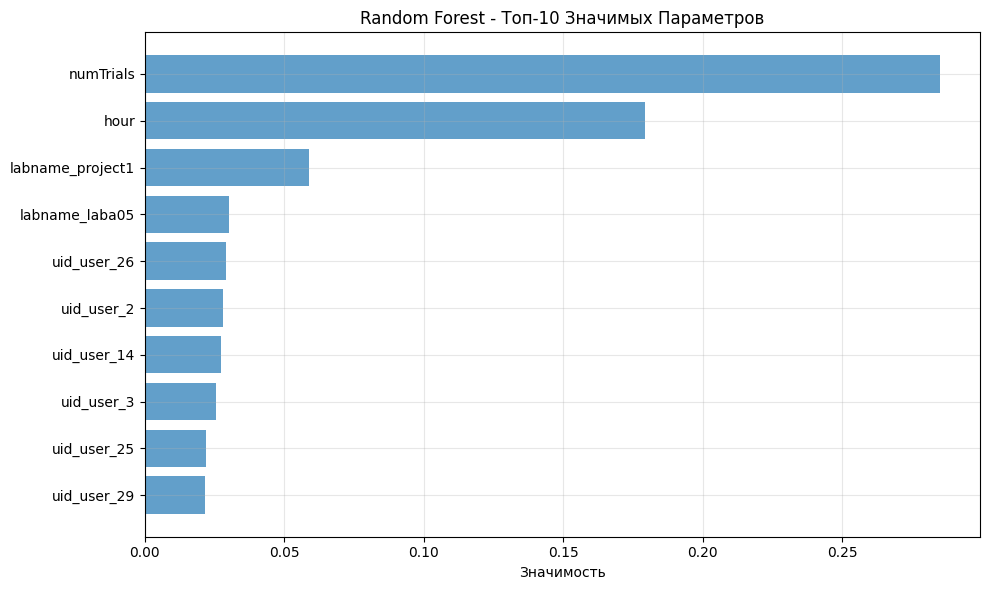

In [44]:
rf_importances = rf.feature_importances_

plot_feature_importance(rf_importances, feature_names, top_n=10,
                        title=f"Random Forest - Топ-10 Значимых Параметров")